In [1]:
!pip -q install keras-tuner

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import keras_tuner as kt

print("TensorFlow version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 963.0 kB/s eta 0:00:00
TensorFlow version: 2.20.0


In [2]:
import urllib.request
import zipfile
import os

url = "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip"

zip_path = "/content/jena_climate.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
file_path = "/content/jena_climate_2009_2016.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (420451, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420451 entries, 0 to 420450
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420451 non-null  object 
 1   p (mbar)         420451 non-null  float64
 2   T (degC)         420451 non-null  float64
 3   Tpot (K)         420451 non-null  float64
 4   Tdew (degC)      420451 non-null  float64
 5   rh (%)           420451 non-null  float64
 6   VPmax (mbar)     420451 non-null  float64
 7   VPact (mbar)     420451 non-null  float64
 8   VPdef (mbar)     420451 non-null  float64
 9   sh (g/kg)        420451 non-null  float64
 10  H2OC (mmol/mol)  420451 non-null  float64
 11  rho (g/m**3)     420451 non-null  float64
 12  wv (m/s)         420451 non-null  float64
 13  max. wv (m/s)    420451 non-null  float64
 14  wd (deg)         420451 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB
None

Missing values:
Date Time     

In [5]:
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")

df = df.sort_values("Date Time")

df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
features = [
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)"
]

data = df[features].copy()

print("Selected features:")
print(features)

print("\nShape:", data.shape)

Selected features:
['T (degC)', 'p (mbar)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)']

Shape: (420451, 8)


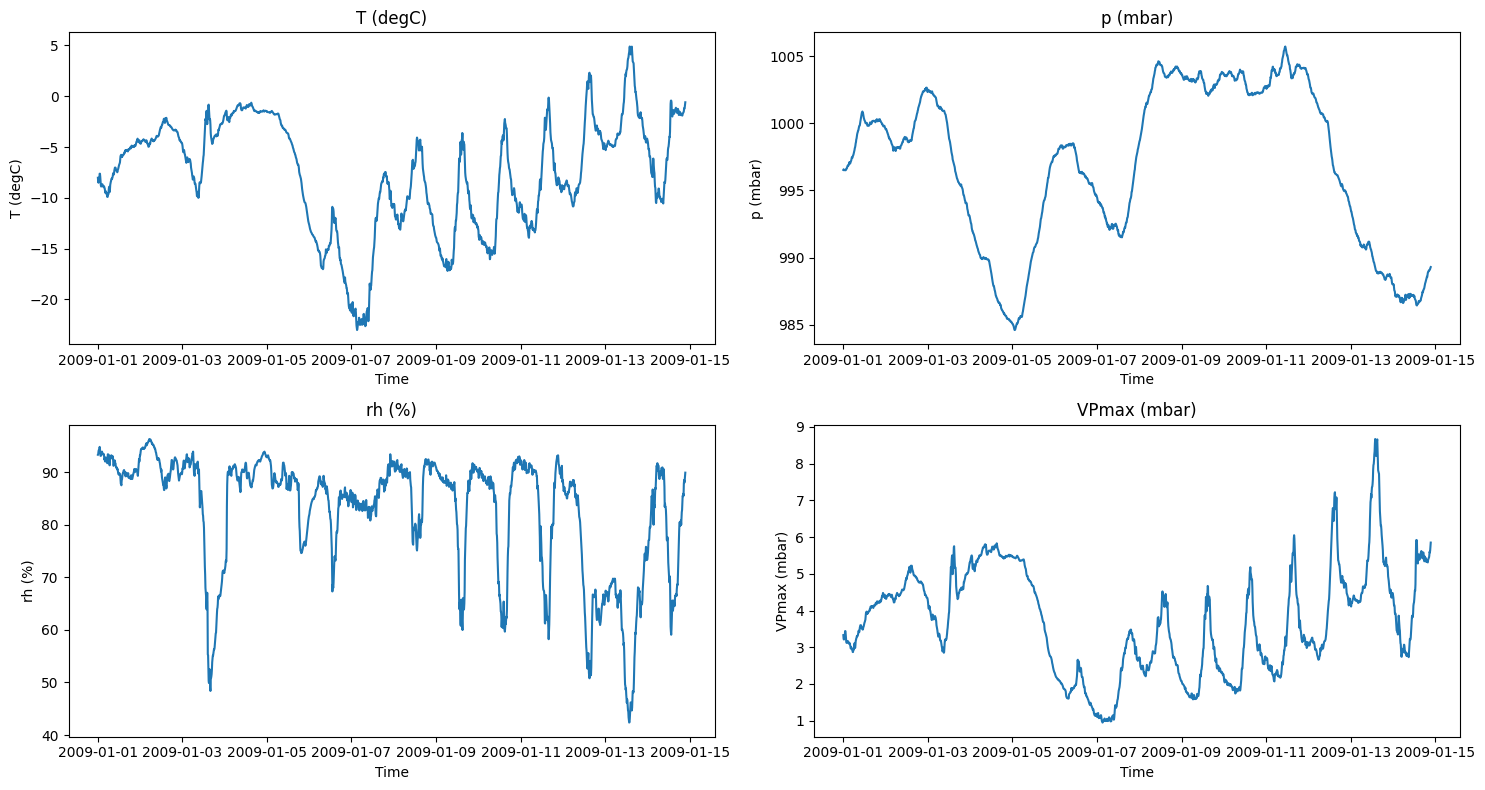

In [7]:
plt.figure(figsize=(15, 8))

for i, feature in enumerate(features[:4]):
    plt.subplot(2, 2, i + 1)
    plt.plot(df["Date Time"][:2000], data[feature][:2000])
    plt.title(feature)
    plt.xlabel("Time")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [8]:
train_size = int(len(data) * 0.8)

train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 336360
Testing samples: 84091


In [9]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)

test_scaled = scaler.transform(test_data)

print("Training shape:", train_scaled.shape)
print("Testing shape:", test_scaled.shape)

Training shape: (336360, 8)
Testing shape: (84091, 8)


In [10]:
def create_sequences(data, sequence_length=24):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [11]:
sequence_length = 24

X_train, y_train = create_sequences(
    train_scaled,
    sequence_length
)

X_test, y_test = create_sequences(
    test_scaled,
    sequence_length
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (336336, 24, 8)
y_train: (336336, 8)
X_test: (84067, 24, 8)
y_test: (84067, 8)


In [12]:
validation_split = 0.2

val_size = int(len(X_train) * validation_split)

X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

X_train_final = X_train[:-val_size]
y_train_final = y_train[:-val_size]

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (269069, 24, 8)
Validation: (67267, 24, 8)
Test: (84067, 24, 8)


In [13]:
model = Sequential([
    LSTM(
        64,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(len(features))
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,368 (122.53 KB)

 Trainable params: 31,368 (122.53 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 139s 31ms/step - loss: 0.0037 - val_loss: 6.2920e-04
Epoch 2/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 138s 33ms/step - loss: 0.0010 - val_loss: 4.7803e-04
Epoch 3/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 129s 31ms/step - loss: 9.6836e-04 - val_loss: 4.1532e-04
Epoch 4/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 151s 33ms/step - loss: 9.4614e-04 - val_loss: 3.9499e-04
Epoch 5/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 133s 32ms/step - loss: 9.4008e-04 - val_loss: 4.1986e-04
Epoch 6/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 128s 30ms/step - loss: 9.3294e-04 - val_loss: 4.1104e-04
Epoch 7/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 128s 31ms/step - loss: 9.2805e-04 - val_loss: 4.1238e-04
Epoch 8/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 129s 31ms/step - loss: 9.2174e-04 - val_loss: 4.1589e-04
Epoch 9/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 131s 31ms/step - loss: 9.2241e-04 - val_loss: 3.9323e-04
Epoch 10/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 140s 31ms/step - loss: 9.1469e-04 - val_loss: 4.1615e-04
Epoch 11/30
4205/

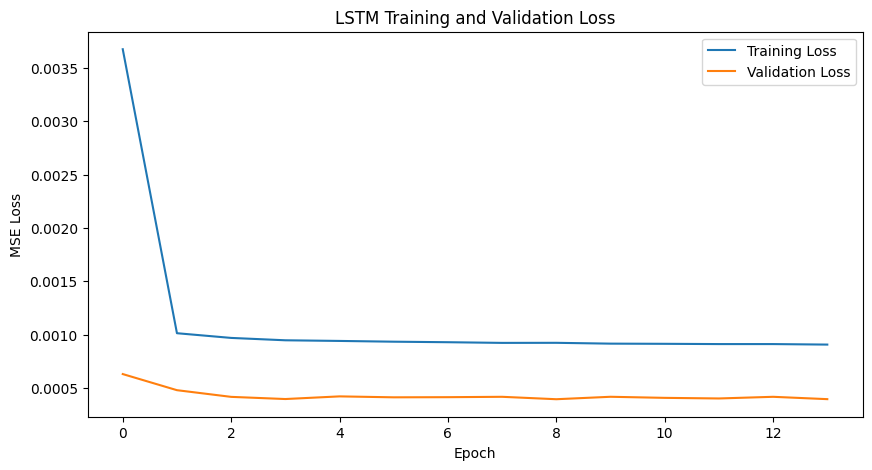

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")

plt.legend()
plt.show()

In [16]:
y_pred_scaled = model.predict(X_test)

print("Prediction shape:", y_pred_scaled.shape)

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
Prediction shape: (84067, 8)


In [17]:
y_test_original = scaler.inverse_transform(y_test)

y_pred_original = scaler.inverse_transform(y_pred_scaled)

In [18]:
mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred_original
    )
)

print("Overall MAE :", mae)
print("Overall RMSE:", rmse)

Overall MAE : 0.6268309384511328
Overall RMSE: 0.977859523307485


In [19]:
results = []

for i, feature in enumerate(features):

    mae_i = mean_absolute_error(
        y_test_original[:, i],
        y_pred_original[:, i]
    )

    rmse_i = np.sqrt(
        mean_squared_error(
            y_test_original[:, i],
            y_pred_original[:, i]
        )
    )

    results.append({
        "Feature": feature,
        "MAE": mae_i,
        "RMSE": rmse_i
    })

results_df = pd.DataFrame(results)

results_df

,Feature,MAE,RMSE
0,T (degC),0.197366,0.276611
1,p (mbar),0.740245,0.917738
2,rh (%),1.010096,1.343359
3,VPmax (mbar),0.391918,0.564570
4,VPact (mbar),0.190979,0.281070
5,rho (g/m**3),1.511252,1.896886
6,wv (m/s),0.389312,0.527923
7,max. wv (m/s),0.583479,0.807271


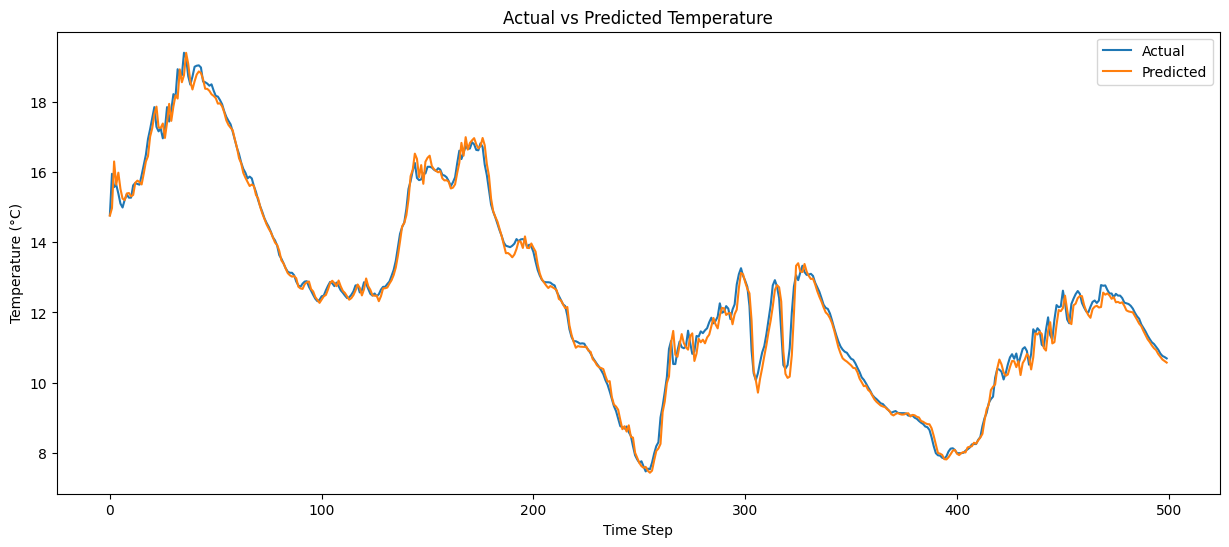

In [20]:
temperature_index = features.index("T (degC)")

plt.figure(figsize=(15, 6))

plt.plot(
    y_test_original[:500, temperature_index],
    label="Actual"
)

plt.plot(
    y_pred_original[:500, temperature_index],
    label="Predicted"
)

plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.title("Actual vs Predicted Temperature")

plt.legend()
plt.show()

In [21]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):

    print(f"\nFold {fold}")

    X_tr = X_train[train_idx]
    y_tr = y_train[train_idx]

    X_va = X_train[val_idx]
    y_va = y_train[val_idx]

    fold_model = Sequential([
        LSTM(
            32,
            input_shape=(X_tr.shape[1], X_tr.shape[2])
        ),
        Dense(len(features))
    ])

    fold_model.compile(
        optimizer="adam",
        loss="mse"
    )

    fold_model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=0
    )

    pred = fold_model.predict(X_va, verbose=0)

    mae_fold = mean_absolute_error(y_va, pred)

    rmse_fold = np.sqrt(
        mean_squared_error(y_va, pred)
    )

    fold_results.append({
        "Fold": fold,
        "MAE": mae_fold,
        "RMSE": rmse_fold
    })

fold_results_df = pd.DataFrame(fold_results)

fold_results_df


Fold 1


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Fold 2


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Fold 3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,Fold,MAE,RMSE
0,1,0.010415,0.019439
1,2,0.009185,0.018476
2,3,0.009686,0.019116


In [22]:
def build_model(hp):

    model = Sequential()

    units = hp.Int(
        "units",
        min_value=32,
        max_value=128,
        step=32
    )

    dropout = hp.Float(
        "dropout",
        min_value=0.1,
        max_value=0.4,
        step=0.1
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.001, 0.0005, 0.0001]
    )

    model.add(
        LSTM(
            units,
            input_shape=(
                X_train.shape[1],
                X_train.shape[2]
            )
        )
    )

    model.add(Dropout(dropout))

    model.add(Dense(len(features)))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse"
    )

    return model

In [23]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    directory="lstm_tuning",
    project_name="multivariate_forecasting",
    overwrite=True
)

tuner.search(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Trial 5 Complete [00h 30m 42s]
val_loss: 0.0003520941536407918

Best val_loss So Far: 0.0003485975612420589
Total elapsed time: 01h 54m 30s


In [24]:
best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("Best LSTM units:",
      best_hps.get("units"))

print("Best dropout:",
      best_hps.get("dropout"))

print("Best learning rate:",
      best_hps.get("learning_rate"))

Best LSTM units: 64
Best dropout: 0.1
Best learning rate: 0.0005


In [25]:
best_model = tuner.hypermodel.build(best_hps)

best_history = best_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 75s 17ms/step - loss: 0.0028 - val_loss: 4.4307e-04
Epoch 2/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 73s 17ms/step - loss: 7.4078e-04 - val_loss: 4.0390e-04
Epoch 3/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 76s 18ms/step - loss: 5.1413e-04 - val_loss: 3.7292e-04
Epoch 4/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 82s 18ms/step - loss: 4.7776e-04 - val_loss: 3.5203e-04
Epoch 5/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 79s 17ms/step - loss: 4.7149e-04 - val_loss: 3.5103e-04
Epoch 6/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 4.6960e-04 - val_loss: 3.5482e-04
Epoch 7/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - loss: 4.6733e-04 - val_loss: 3.5100e-04
Epoch 8/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 4.6642e-04 - val_loss: 3.5332e-04
Epoch 9/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 73s 17ms/step - loss: 4.6436e-04 - val_loss: 3.5430e-04
Epoch 10/30
4205/4205 ━━━━━━━━━━━━━━━━━━━━ 75s 18ms/step - loss: 4.6365e-04 - val_loss: 3.5235e-04
Epoch 11/30
4205/4205 ━

In [26]:
final_pred_scaled = best_model.predict(X_test)

final_pred = scaler.inverse_transform(
    final_pred_scaled
)

actual = scaler.inverse_transform(
    y_test
)

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step


In [27]:
final_mae = mean_absolute_error(
    actual,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        actual,
        final_pred
    )
)

print("=" * 40)
print("FINAL MODEL PERFORMANCE")
print("=" * 40)

print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")

FINAL MODEL PERFORMANCE
MAE  : 0.3910
RMSE : 0.6606


In [28]:
final_results = []

for i, feature in enumerate(features):

    mae = mean_absolute_error(
        actual[:, i],
        final_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual[:, i],
            final_pred[:, i]
        )
    )

    final_results.append([
        feature,
        mae,
        rmse
    ])

final_results_df = pd.DataFrame(
    final_results,
    columns=["Feature", "MAE", "RMSE"]
)

final_results_df

,Feature,MAE,RMSE
0,T (degC),0.182591,0.250416
1,p (mbar),0.145177,0.193661
2,rh (%),0.678310,1.045412
3,VPmax (mbar),0.220148,0.355360
4,VPact (mbar),0.102222,0.159927
5,rho (g/m**3),0.855224,1.116431
6,wv (m/s),0.377953,0.518105
7,max. wv (m/s),0.566694,0.794671


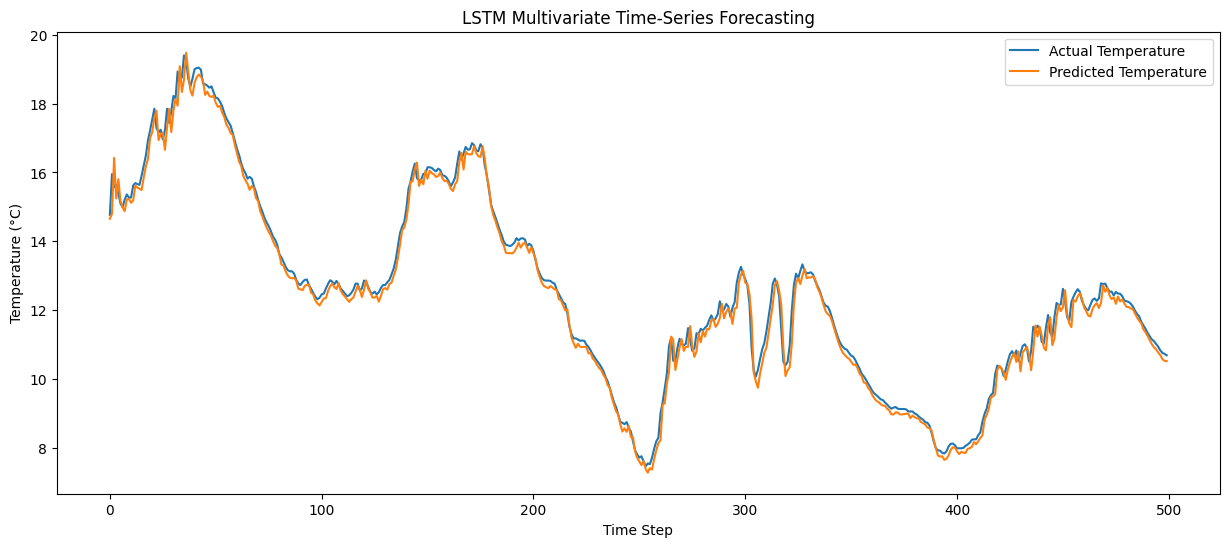

In [29]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual[:500, temperature_index],
    label="Actual Temperature"
)

plt.plot(
    final_pred[:500, temperature_index],
    label="Predicted Temperature"
)

plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.title("LSTM Multivariate Time-Series Forecasting")

plt.legend()
plt.show()

In [30]:
best_model.save(
    "/content/multivariate_lstm_forecasting.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [32]:
final_results_df.to_csv(
    "/content/lstm_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
